In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

## Лемма о рукопожатиях

In [ ]:

import networkx as nx
import random

random.seed(42) # Фиксируем состояние для воспроизводимости
graph = nx.erdos_renyi_graph(10, 0.3) # Создаём случайный граф с 10 вершинами и вероятностью ребра 0.3

# Считаем сумму степеней всех вершин
sum_degrees = sum(dict(graph.degree()).values())

# Считаем удвоенное количество рёбер
double_edges = 2 * graph.number_of_edges()

print(f"Сумма степеней: {sum_degrees}") # должно получиться 34
print(f"Удвоенное количество рёбер: {double_edges}") # должно получиться 34


Сумма степеней: 34
Удвоенное количество рёбер: 34


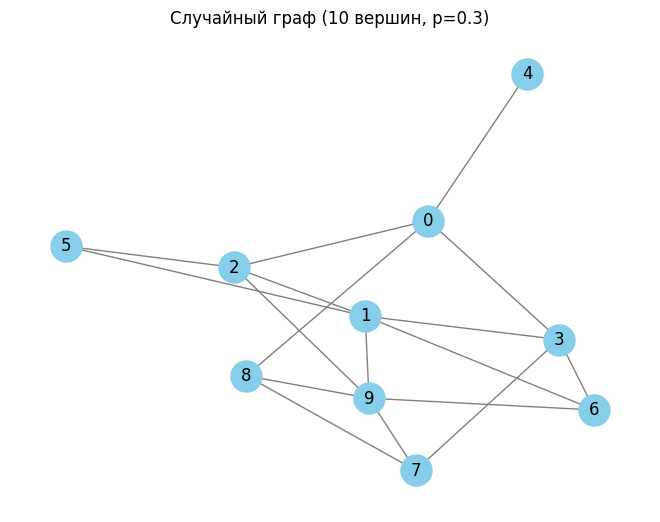

In [3]:
import matplotlib.pyplot as plt

# Устанавливаем позиции узлов для красивого отображения (алгоритм пружинок)
pos = nx.spring_layout(graph, seed=42) 

# Рисуем сам граф
nx.draw(graph, pos, with_labels=True, node_color='skyblue', node_size=500, edge_color='gray')

# Показываем окно с рисунком
plt.title("Случайный граф (10 вершин, p=0.3)")
plt.show()

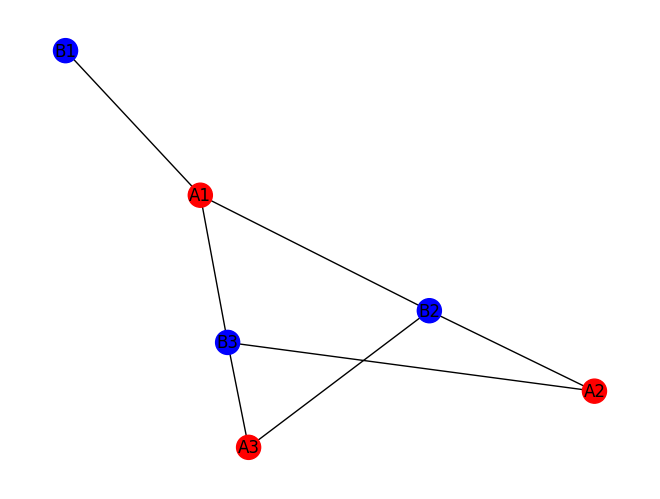

In [ ]:
# пример визуализации двудольного графа
import networkx as nx
import matplotlib.pyplot as plt

# Создаём граф
G = nx.Graph()

# Добавляем вершины
G.add_nodes_from(['A1', 'A2', 'A3', 'B1', 'B2', 'B3'])

# Добавляем рёбра
G.add_edges_from([('A1', 'B1'), ('A1', 'B2'), ('A1', 'B3'), ('A2', 'B2'), ('A2', 'B3'), ('A3', 'B2'), ('A3', 'B3')])

# Определяем цвета для вершин
node_colors = ['red' if node.startswith('A') else 'blue' for node in G.nodes]

# Рисуем граф
nx.draw(G, with_labels=True, node_color=node_colors)

# Отображаем граф
plt.show()


In [5]:
#Число рёбер в полном графе


import sys

def main():
    # Читаем N из стандартного ввода
    line = sys.stdin.readline()
    if not line:
        return
    
    n = int(line.strip())
    
    # Если вершин меньше 2, рёбер быть не может
    if n < 2:
        print(0)
        return
    
    # Вычисляем по формуле. 
    # Используем целочисленное деление //, чтобы на выходе не было .0
    result = n * (n - 1) // 2
    print(result)

if __name__ == '__main__':
    main()

Алгоритм решения:Считываем список всех уникальных пользователей (их количество — $n$).
Считываем список всех уникальных фильмов (их количество — $m$).
Считываем данные о просмотрах. 
Для каждого пользователя проверяем, совпадает ли количество просмотренных им фильмов с общим количеством доступных фильмов $m$.
Если хотя бы один пользователь посмотрел меньше фильмов, чем есть в списке, или если количество записей о пользователях не совпадает с исходным списком — граф не является полным.

In [7]:
import sys
import io

def solve(test_input=None):
    # Если данные переданы в функцию — используем их, иначе читаем из стандартного ввода
    if test_input:
        f = io.StringIO(test_input)
        input_data = f.read().splitlines()
    else:
        input_data = sys.stdin.read().splitlines()
    
    if not input_data:
        return

    print(f"--- ШАГ 1: Весь список строк из входа ---")
    print(f"Объект input_data: {input_data}\n")

    # 1. Список пользователей
    users_list = input_data[0].split()
    num_users = len(users_list)
    print(f"--- ШАГ 2: Обработка пользователей ---")
    print(f"Список: {users_list}, Всего (n): {num_users}\n")
    
    # 2. Список фильмов
    movies_list = input_data[1].split()
    num_movies = len(movies_list)
    print(f"--- ШАГ 3: Обработка фильмов ---")
    print(f"Список: {movies_list}, Всего (m): {num_movies}\n")

    watched_counts = 0
    print(f"--- ШАГ 4: Цикл по пользователям ---")
    
    for i in range(2, 2 + num_users):
        if i >= len(input_data):
            break
            
        parts = input_data[i].split()
        user_name = parts[0]
        k_i = int(parts[1]) # Сколько фильмов он якобы посмотрел
        
        print(f"Проверяем строку {i}: {parts}")
        print(f"  Юзер: {user_name}, заявляет фильмов: {k_i}")

        if k_i == num_movies:
            watched_counts += 1
            print(f"  Результат: СОВПАЛО (уже {watched_counts} чел. посмотрели всё)")
        else:
            print(f"  Результат: НЕ СОВПАЛО (нужно было {num_movies})")

    print(f"\n--- ФИНАЛ ---")
    print(f"Всего 'полных' пользователей: {watched_counts} из {num_users}")
    
    if watched_counts == num_users:
        print("ИТОГ: YES")
    else:
        print("ИТОГ: NO")
    print("-" * 30)

# Примеры для проверки
if __name__ == '__main__':
    # Пример 1: Полный граф (все посмотрели всё)
    example1 = """User1 User2
Movie1 Movie2
User1 2 Movie1 Movie2
User2 2 Movie1 Movie2"""

    # Пример 2: Неполный граф (User2 посмотрел только 1 фильм)
    example2 = """User1 User2
Movie1 Movie2
User1 2 Movie1 Movie2
User2 1 Movie1"""

    print("ЗАПУСК ПРИМЕРА №1:")
    solve(example1)
    
    print("\nЗАПУСК ПРИМЕРА №2:")
    solve(example2)

ЗАПУСК ПРИМЕРА №1:
--- ШАГ 1: Весь список строк из входа ---
Объект input_data: ['User1 User2', 'Movie1 Movie2', 'User1 2 Movie1 Movie2', 'User2 2 Movie1 Movie2']

--- ШАГ 2: Обработка пользователей ---
Список: ['User1', 'User2'], Всего (n): 2

--- ШАГ 3: Обработка фильмов ---
Список: ['Movie1', 'Movie2'], Всего (m): 2

--- ШАГ 4: Цикл по пользователям ---
Проверяем строку 2: ['User1', '2', 'Movie1', 'Movie2']
  Юзер: User1, заявляет фильмов: 2
  Результат: СОВПАЛО (уже 1 чел. посмотрели всё)
Проверяем строку 3: ['User2', '2', 'Movie1', 'Movie2']
  Юзер: User2, заявляет фильмов: 2
  Результат: СОВПАЛО (уже 2 чел. посмотрели всё)

--- ФИНАЛ ---
Всего 'полных' пользователей: 2 из 2
ИТОГ: YES
------------------------------

ЗАПУСК ПРИМЕРА №2:
--- ШАГ 1: Весь список строк из входа ---
Объект input_data: ['User1 User2', 'Movie1 Movie2', 'User1 2 Movie1 Movie2', 'User2 1 Movie1']

--- ШАГ 2: Обработка пользователей ---
Список: ['User1', 'User2'], Всего (n): 2

--- ШАГ 3: Обработка фильмов --

In [8]:
# алгоритм дейкстры


import heapq

def dijkstra(graph, start):
    distance = {vertex: float('inf') for vertex in graph}
    distance[start] = 0
    priority_queue = [(0, start)]  # (расстояние, вершина)

    while priority_queue:
        current_distance, current_vertex = heapq.heappop(priority_queue)

        # Если найден более короткий путь, пропускаем
        if current_distance > distance[current_vertex]:
            continue

        for neighbor, weight in graph[current_vertex]:
            distance_to_neighbor = current_distance + weight

            if distance_to_neighbor < distance[neighbor]:
                distance[neighbor] = distance_to_neighbor
                heapq.heappush(priority_queue, (distance_to_neighbor, neighbor))

    return distance

# Пример использования
graph = {
    'A': [('B', 1), ('C', 4)],
    'B': [('C', 2), ('D', 5)],
    'C': [('D', 1)],
    'D': []
}

distances = dijkstra(graph, 'A')
print(distances)  # {'A': 0, 'B': 1, 'C': 3, 'D': 4}


{'A': 0, 'B': 1, 'C': 3, 'D': 4}


In [10]:
# Алгоритм Беллмана-Форда (с подробной визуализацией)

"""
Термины:

graph (граф) — структура данных, где:
    ключ (vertex) — вершина (узел, точка)
    значение — список рёбер (соседей)

vertex (вершина) — узел графа (например: 'A', 'B')

neighbor (сосед) — вершина, в которую ведёт ребро

weight (вес) — стоимость/длина перехода между вершинами
    может быть отрицательной

Пример:
'A': [('B', 4)] означает:
    из A можно попасть в B с "ценой" 4
"""


def bellman_ford_verbose(graph, source):
    # 1. Инициализация расстояний
    distance = {vertex: float('inf') for vertex in graph}
    distance[source] = 0

    print("Начальные расстояния:")
    print(distance)
    print("-" * 50)

    # 2. Основной цикл (V-1 итераций)
    for i in range(len(graph) - 1):
        print(f"\nИтерация {i + 1}")
        updated = False  # для оптимизации (если изменений нет)

        for vertex in graph:
            for neighbor, weight in graph[vertex]:

                old_distance = distance[neighbor]
                new_distance = distance[vertex] + weight

                print(f"Проверяем: {vertex} → {neighbor} (вес {weight})")

                # RELAXATION
                if new_distance < old_distance:
                    print(
                        f"  Улучшение: {old_distance} → {new_distance}"
                    )
                    distance[neighbor] = new_distance
                    updated = True
                else:
                    print(
                        f"  Без изменений: текущее {old_distance}, новое {new_distance}"
                    )

        print("Текущие расстояния:", distance)

        # Оптимизация: если нет изменений — можно остановиться
        if not updated:
            print("Изменений нет → досрочный выход")
            break

        print("-" * 50)

    # 3. Проверка отрицательных циклов
    print("\nПроверка на отрицательные циклы:")
    for vertex in graph:
        for neighbor, weight in graph[vertex]:
            if distance[vertex] + weight < distance[neighbor]:
                raise ValueError("Граф содержит отрицательный цикл")

    print("Отрицательных циклов нет")
    print("-" * 50)

    return distance


# Пример
graph = {
    'A': [('B', 4), ('C', 2)],
    'B': [('C', -1), ('D', 2)],
    'C': [('D', 3)],
    'D': []
}

distances = bellman_ford_verbose(graph, 'A')

print("\nФинальный результат:")
print(distances)

Начальные расстояния:
{'A': 0, 'B': inf, 'C': inf, 'D': inf}
--------------------------------------------------

Итерация 1
Проверяем: A → B (вес 4)
  Улучшение: inf → 4
Проверяем: A → C (вес 2)
  Улучшение: inf → 2
Проверяем: B → C (вес -1)
  Без изменений: текущее 2, новое 3
Проверяем: B → D (вес 2)
  Улучшение: inf → 6
Проверяем: C → D (вес 3)
  Улучшение: 6 → 5
Текущие расстояния: {'A': 0, 'B': 4, 'C': 2, 'D': 5}
--------------------------------------------------

Итерация 2
Проверяем: A → B (вес 4)
  Без изменений: текущее 4, новое 4
Проверяем: A → C (вес 2)
  Без изменений: текущее 2, новое 2
Проверяем: B → C (вес -1)
  Без изменений: текущее 2, новое 3
Проверяем: B → D (вес 2)
  Без изменений: текущее 5, новое 6
Проверяем: C → D (вес 3)
  Без изменений: текущее 5, новое 5
Текущие расстояния: {'A': 0, 'B': 4, 'C': 2, 'D': 5}
Изменений нет → досрочный выход

Проверка на отрицательные циклы:
Отрицательных циклов нет
--------------------------------------------------

Финальный резу

In [ ]:
# Алгоритм Флойда — Уоршелла

import numpy as np

def floyd_warshall(graph):
    num_vertices = len(graph)
    dist = np.array(graph)

    for k in range(num_vertices):
        for i in range(num_vertices):
            for j in range(num_vertices):
                if dist[i][k] + dist[k][j] < dist[i][j]:
                    dist[i][j] = dist[i][k] + dist[k][j]

    return dist

# Пример использования
graph = [
    [0, 3, float('inf'), 5],
    [2, 0, float('inf'), 4],
    [float('inf'), 1, 0, float('inf')],
    [float('inf'), float('inf'), 2, 0]
]

shortest_paths = floyd_warshall(graph)
print(shortest_paths)


[[0. 3. 7. 5.]
 [2. 0. 6. 4.]
 [3. 1. 0. 5.]
 [5. 3. 2. 0.]]


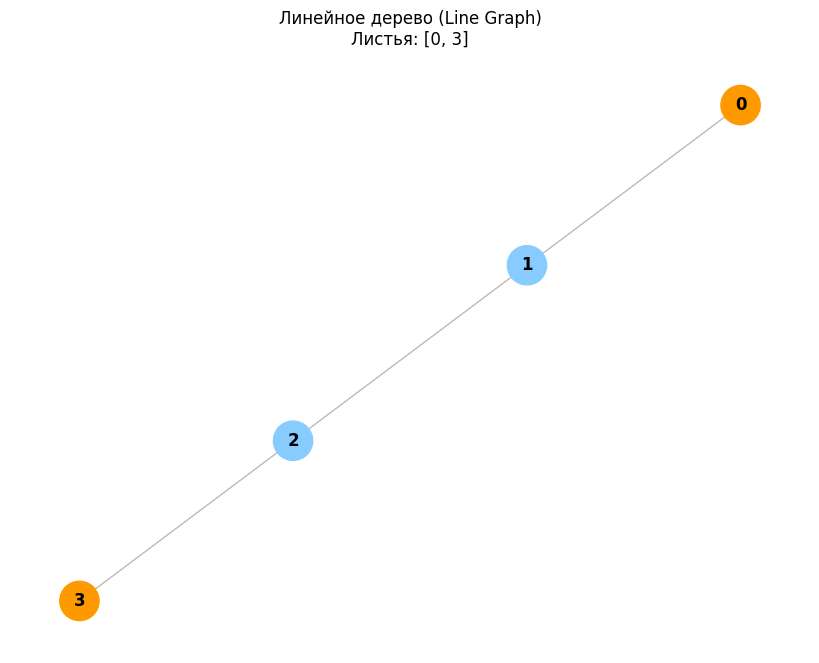

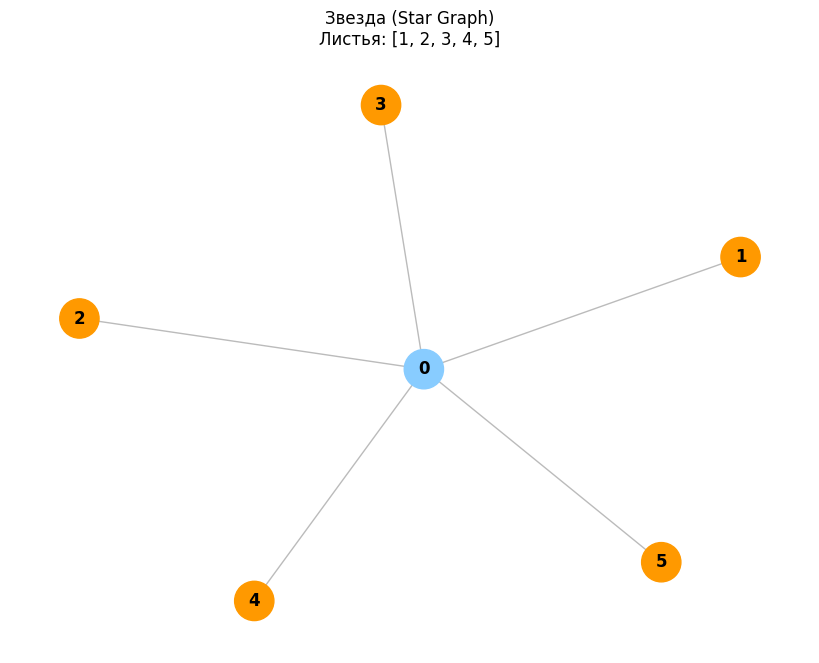

In [15]:
import sys
import io
import networkx as nx
import matplotlib.pyplot as plt

def find_and_visualize_leaves(matrix_input, title="Граф"):
    # 1. Парсинг данных
    f = io.StringIO(matrix_input.strip())
    lines = f.readlines()
    if not lines: return
    
    n = int(lines[0].strip())
    adj_matrix = []
    for i in range(n):
        adj_matrix.append([int(x) for x in lines[i+1].split()])

    # 2. Поиск листьев
    leaves = []
    for i in range(n):
        if sum(adj_matrix[i]) == 1:
            leaves.append(i)

    # 3. Создание графа через NetworkX
    G = nx.Graph()
    for i in range(n):
        for j in range(i + 1, n): # Берем только верхний треугольник матрицы
            if adj_matrix[i][j] == 1:
                G.add_edge(i, j)

    # 4. Визуализация
    plt.figure(figsize=(8, 6))
    
    # Определяем позиции узлов (layout)
    pos = nx.spring_layout(G) 
    
    # Цвета: листья — оранжевые, остальные — голубые
    node_colors = ['#FF9900' if node in leaves else '#88CCFF' for node in G.nodes()]

    

    nx.draw(G, pos, 
            with_labels=True, 
            node_color=node_colors, 
            node_size=800, 
            font_weight='bold',
            edge_color='#BBBBBB')
    
    plt.title(f"{title}\nЛистья: {leaves}")
    plt.show()

# --- ТЕСТОВЫЕ ДАННЫЕ ---

example_line = """4
0 1 0 0
1 0 1 0
0 1 0 1
0 0 1 0"""

example_star = """6
0 1 1 1 1 1
1 0 0 0 0 0
1 0 0 0 0 0
1 0 0 0 0 0
1 0 0 0 0 0
1 0 0 0 0 0"""

if __name__ == "__main__":
    # Линейный граф: 0 и 3 будут листьями
    find_and_visualize_leaves(example_line, "Линейное дерево (Line Graph)")
    
    # Звезда: 1, 2, 3, 4, 5 будут листьями
    find_and_visualize_leaves(example_star, "Звезда (Star Graph)")

Кратчайший путь от 1 до 4: [1, 3, 4]


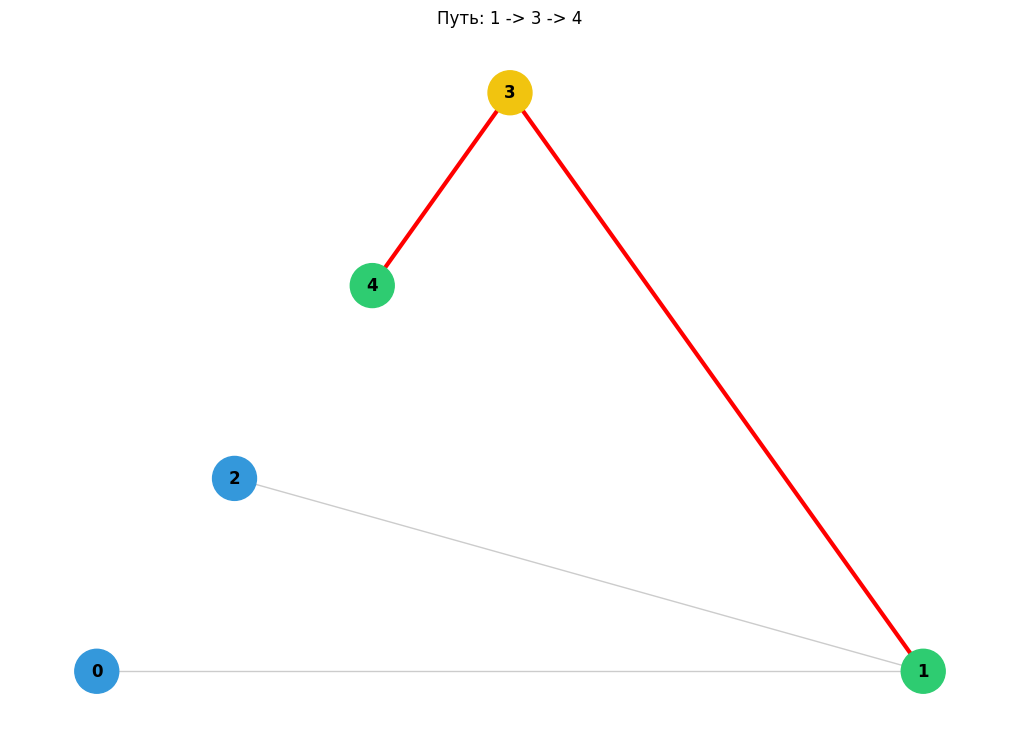

In [19]:
import networkx as nx
import matplotlib.pyplot as plt
from collections import deque
import io

def solve_and_draw(input_str):
    # 1. Парсинг входных данных
    lines = input_str.strip().split('\n')
    n = int(lines[0])
    matrix = [list(map(int, line.split())) for line in lines[1:n+1]]
    start_node, end_node = map(int, lines[n+1].split())

    # 2. Поиск кратчайшего пути (BFS)
    queue = deque([start_node])
    parents = {start_node: None}
    found = False

    while queue:
        curr = queue.popleft()
        if curr == end_node:
            found = True
            break
        
        for neighbor, is_connected in enumerate(matrix[curr]):
            if is_connected and neighbor not in parents:
                parents[neighbor] = curr
                queue.append(neighbor)

    # Восстанавливаем путь
    path = []
    if found:
        temp = end_node
        while temp is not None:
            path.append(temp)
            temp = parents[temp]
        path = path[::-1]
    
    print(f"Кратчайший путь от {start_node} до {end_node}: {path if found else 'NO PATH'}")

    # 3. Визуализация
    G = nx.Graph()
    for i in range(n):
        for j in range(i + 1, n):
            if matrix[i][j] == 1:
                G.add_edge(i, j)

    plt.figure(figsize=(10, 7))
    pos = nx.planar_layout(G) # Для деревьев хорошо подходит planar или shell layout

    # Подготовка цветов
    edge_colors = []
    path_edges = list(zip(path, path[1:])) if found else []
    
    # Красим ребра: если ребро входит в путь — оно красное и толстое
    for u, v in G.edges():
        if (u, v) in path_edges or (v, u) in path_edges:
            edge_colors.append('red')
        else:
            edge_colors.append('#CCCCCC')

    # Красим узлы: старт и финиш — зеленые, остальные — голубые
    node_colors = []
    for node in G.nodes():
        if node == start_node or node == end_node:
            node_colors.append('#2ecc71')
        elif node in path:
            node_colors.append('#f1c40f') # Желтый для промежуточных точек пути
        else:
            node_colors.append('#3498db')

    

    nx.draw(G, pos, with_labels=True, node_color=node_colors, 
            edge_color=edge_colors, width=[3 if c=='red' else 1 for c in edge_colors],
            node_size=1000, font_size=12, font_weight='bold')
    
    plt.title(f"Путь: {' -> '.join(map(str, path)) if found else 'Путь не найден'}")
    plt.show()

# --- Пример использования ---
example_data = """5
0 1 0 0 0
1 0 1 1 0
0 1 0 0 0
0 1 0 0 1
0 0 0 1 0
1 4"""

if __name__ == "__main__":
    solve_and_draw(example_data)

In [22]:
import sys
from collections import defaultdict, deque

def main():
    input = sys.stdin.read
    data = input().split()

    idx = 0

    # 1. Читаем N
    n = int(data[idx])
    idx += 1

    # 2. Читаем вершины
    vertices = data[idx:idx + n]
    idx += n

    # 3. Читаем M
    m = int(data[idx])
    idx += 1

    # 4. Структуры
    graph = defaultdict(list)
    degree = {v: 0 for v in vertices}

    # 5. Читаем рёбра
    for _ in range(m):
        u = data[idx]
        v = data[idx + 1]
        idx += 2

        graph[u].append(v)
        graph[v].append(u)

        degree[u] += 1
        degree[v] += 1

    # ---- ПРОВЕРКА 1: дерево ли это ----

    # условие по рёбрам
    if m != n - 1:
        print("NO")
        return

    # проверка связности (BFS)
    visited = set()
    queue = deque([vertices[0]])

    while queue:
        node = queue.popleft()
        if node in visited:
            continue

        visited.add(node)

        for nei in graph[node]:
            if nei not in visited:
                queue.append(nei)

    if len(visited) != n:
        print("NO")
        return

    # ---- ПРОВЕРКА 2: есть ли лист ----

    for v in degree:
        if degree[v] == 1:
            print("YES")
            return

    print("NO")


if __name__ == '__main__':
    main()

IndexError: list index out of range